# Analiza tekstów medycznych: NER i klasyfikacja (Etapy 1–4)

Ten notatnik **demonstruje** Etapy 1–4:
1. **Przygotowanie danych tekstowych**,
2. **Rozpoznawanie jednostek medycznych (NER)**,
3. **Klasyfikacja dokumentów**,
4. **Wizualizacja i interpretacja wyników**.

Zmodyfikowano dla zestawu danych: variant_13_infectious.csv

## 0. Środowisko i biblioteki

In [2]:

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    import spacy
    from spacy.lang.en import English
    from spacy.pipeline import EntityRuler
    SPACY_AVAILABLE = True
except Exception:
    SPACY_AVAILABLE = False
    print("spaCy niedostępne — użyjemy fallbacku słownikowego.")

plt.rcParams["figure.figsize"] = (7, 4)
print("Środowisko gotowe.")

Środowisko gotowe.


## 1. Etap: Przygotowanie danych tekstowych

In [3]:
df = pd.read_csv("variant_13_infectious.csv")

def clean_text(s):
    s = str(s).lower()
    s = s.replace("\n", " ").replace("\t", " ")
    s = re.sub(r"https?://\S+", " ", s)
    s = re.sub(r"[0-9]+\s*mg", " dose ", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["clean"] = df["text"].apply(clean_text)
df.head()

,text,label,clean
0,Fever and cough for 5 days. COVID-19 PCR posit...,viral,fever and cough for 5 days covid19 pcr positiv...
1,"High fever, sore throat, exudative tonsils. St...",bacterial,high fever sore throat exudative tonsils strep...
2,Diarrhea and vomiting after street food. Stool...,bacterial,diarrhea and vomiting after street food stool ...
3,Persistent fever after mosquito bite. Dengue N...,viral,persistent fever after mosquito bite dengue ns...
4,"Night sweats, weight loss, productive cough. S...",bacterial,night sweats weight loss productive cough sput...


### 1.2 Tokenizacja i (opcjonalnie) lematyzacja

In [4]:

def build_spacy_pipeline():
    nlp = English()
    ruler = nlp.add_pipe("entity_ruler")
    patterns = [
        {"label": "DISEASE", "pattern": "covid-19"},
        {"label": "DISEASE", "pattern": "streptococcal infection"},
        {"label": "DISEASE", "pattern": "salmonella"},
        {"label": "DISEASE", "pattern": "dengue"},
        {"label": "DISEASE", "pattern": "tuberculosis"},
        {"label": "TEST", "pattern": "pcr"},
        {"label": "TEST", "pattern": "stool culture"},
        {"label": "TEST", "pattern": "ns1"},
        {"label": "TEST", "pattern": "sputum afb"}
    ]
    ruler.add_patterns(patterns)
    return nlp

if SPACY_AVAILABLE:
    try:
        nlp = build_spacy_pipeline()
        tokens = [[t.text for t in nlp(text)] for text in df["clean"].tolist()]
        df["tokens"] = tokens
        print("spaCy pipeline działa (EntityRuler).")
    except Exception as e:
        print("Błąd spaCy, używam prostego split:", e)
        df["tokens"] = df["clean"].str.split()
else:
    df["tokens"] = df["clean"].str.split()

df[["clean","tokens"]].head()

spaCy pipeline działa (EntityRuler).


,clean,tokens
0,fever and cough for 5 days covid19 pcr positiv...,"[fever, and, cough, for, 5, days, covid19, pcr..."
1,high fever sore throat exudative tonsils strep...,"[high, fever, sore, throat, exudative, tonsils..."
2,diarrhea and vomiting after street food stool ...,"[diarrhea, and, vomiting, after, street, food,..."
3,persistent fever after mosquito bite dengue ns...,"[persistent, fever, after, mosquito, bite, den..."
4,night sweats weight loss productive cough sput...,"[night, sweats, weight, loss, productive, coug..."


## 2. Etap: Rozpoznawanie jednostek medycznych (NER)

In [5]:

def simple_dict_ner(texts):
    lex = {
        "DISEASE": ["covid-19", "streptococcal infection", "salmonella", "dengue", "tuberculosis"],
        "TEST": ["pcr", "stool culture", "ns1", "sputum afb"]
    }
    results = []
    for s in texts:
        low = s.lower()
        ents = []
        for label, words in lex.items():
            for w in words:
                if w in low:
                    ents.append((w, label))
        results.append(ents)
    return results

if SPACY_AVAILABLE:
    try:
        ents_demo = []
        for text in df["clean"].tolist():
            doc = nlp(text)
            ents_demo.append([(ent.text, ent.label_) for ent in doc.ents])
        df["entities"] = ents_demo
    except Exception as e:
        print("spaCy NER demo nie działa – fallback:", e)
        df["entities"] = simple_dict_ner(df["clean"].tolist())
else:
    df["entities"] = simple_dict_ner(df["clean"].tolist())

df[["text","entities"]].head(10)

,text,entities
0,Fever and cough for 5 days. COVID-19 PCR posit...,"[(pcr, TEST)]"
1,"High fever, sore throat, exudative tonsils. St...","[(streptococcal infection, DISEASE)]"
2,Diarrhea and vomiting after street food. Stool...,"[(stool culture, TEST), (salmonella, DISEASE)]"
3,Persistent fever after mosquito bite. Dengue N...,"[(dengue, DISEASE), (ns1, TEST)]"
4,"Night sweats, weight loss, productive cough. S...","[(sputum afb, TEST), (tuberculosis, DISEASE)]"


## 3. Etap: Klasyfikacja dokumentów (TF–IDF + Logistic Regression)

In [6]:

X = df["clean"].values
y = df["label"].values

def safe_stratified_split(X, y, test_size=0.3, random_state=42):
    vc = pd.Series(y).value_counts()
    if (vc < 2).any():
        return train_test_split(X, y, test_size=test_size, random_state=random_state)
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

X_train, X_test, y_train, y_test = safe_stratified_split(X, y)

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1)
clf = LogisticRegression(max_iter=1000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.5

Raport klasyfikacji:
              precision    recall  f1-score   support

   bacterial      0.500     1.000     0.667         1
       viral      0.000     0.000     0.000         1

    accuracy                          0.500         2
   macro avg      0.250     0.500     0.333         2
weighted avg      0.250     0.500     0.333         2



c:\Users\Patryk\Desktop\Sem3\IRwZM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Patryk\Desktop\Sem3\IRwZM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Patryk\Desktop\Sem3\IRwZM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

## 4. Etap: Wizualizacja i interpretacja wyników

Przykładowe podświetlenie encji:

- fever and cough for 5 days covid19 [pcr<TEST>] positive home isolation advised
- high fever sore throat exudative tonsils [streptococcal infection<DISEASE>] confirmed
- diarrhea and vomiting after street food [stool culture<TEST>] [salmonella<DISEASE>]


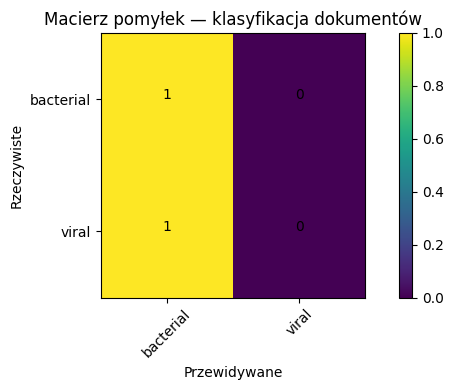

In [7]:

def highlight_entities(text, entities):
    out = text
    entities_sorted = sorted(entities, key=lambda x: len(x[0]), reverse=True)
    for ent, label in entities_sorted:
        out = out.replace(ent, f"[{ent}<{label}>]")
    return out

print("Przykładowe podświetlenie encji:\n")
for i in range(min(3, len(df))):
    t = df.loc[i, "clean"]
    ents = df.loc[i, "entities"]
    ents = [(e if isinstance(e, str) else e[0], e[1]) if isinstance(e, tuple) else (e[0], e[1]) for e in ents]
    print("-", highlight_entities(t, ents))

cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y)))
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Macierz pomyłek — klasyfikacja dokumentów")
plt.colorbar()
tick_marks = np.arange(len(sorted(np.unique(y))))
plt.xticks(tick_marks, sorted(np.unique(y)), rotation=45)
plt.yticks(tick_marks, sorted(np.unique(y)))
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 horizontalalignment="center")
plt.ylabel("Rzeczywiste")
plt.xlabel("Przewidywane")
plt.tight_layout()
plt.show()